In [1]:
import pandas as pd
import glob

def printShape(df, cols=[], msg=''):
    
    print(df.shape, end='\t')
    for col in cols:
        print(col, df[col].nunique(), end='\t')
        
    print(msg)
    return df

In [2]:
import matplotlib

cm = 1/2.54  # centimeters in inches
font = {'size': 7}
matplotlib.rc('font', **font)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['grid.linewidth'] = 0.5
matplotlib.rcParams['axes.linewidth'] = 0.5

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

In [3]:
def codeResponse(df):
    
    def codeSingleRes(x):
        if x == 'Strongly agree': return 3
        elif x== 'Agree': return 2
        elif x== 'Somewhat agree': return 1
        elif x== 'Neutral': return 0
        elif x== 'Somewhat disagree': return -1
        elif x== 'Disagree': return -2
        elif x== 'Strongly disagree': return -3
        
    cols = [
        'TRUST_FINDING_1','TRUST_FINDING_2','TRUST_FINDING_3',
        'TRUST_AUTHOR_1','TRUST_AUTHOR_2','TRUST_AUTHOR_3'
    ]
    
    for col in cols:
        df[col] = df[col].apply(codeSingleRes)
        
    return df

def codeCondition(df):
    
    
    def codeSingleCondition(x):
        try:
            return int(x[-1])
        except:
            return 0
    
    df = df.assign(condition=lambda df: df.condition.apply(codeSingleCondition))
    return df

# Load data

Conditions:
- 1 is not disclosed
- 2 is disclosed

In [ ]:
survey = (
    pd.read_csv(
        './data/survey.csv', usecols=[
        'StartDate', 'condition', 'counter',
        'TRUST_FINDING_1', 'TRUST_AUTHOR_1', 'TRUST_FINDING_2', 'TRUST_AUTHOR_2',
        'TRUST_FINDING_3', 'TRUST_AUTHOR_3',
        'firstArticle', 'secondArticle','thirdArticle',
        'Q65', 'Q66','Q67', 'Q68']
    )

    .pipe(codeResponse).pipe(printShape)
)

(910, 16)	


In [5]:
pilot = (
    pd.read_csv(
        './data/pilot.csv',
        usecols=[
        'StartDate', 'condition', 'counter',
        'TRUST_FINDING_1', 'TRUST_AUTHOR_1', 'TRUST_FINDING_2', 'TRUST_AUTHOR_2',
        'TRUST_FINDING_3', 'TRUST_AUTHOR_3',
        'Q65', 'Q66','Q67', 'Q68'
    ])

    .pipe(codeResponse).pipe(printShape)
)

(288, 13)	


## Get the demographics

In [6]:
demographics = (
    survey[['Q65', 'Q66','Q67', 'Q68']]
    .assign(Age=lambda df: df['Q66'].apply(lambda x: 2024-int(x) if int(x) > 100 else int(x)))
)

In [7]:
demographics.describe([0.01, 0.025, 0.975, 0.99])
# mean: 31.863
# median: 33

,Q66,Age
count,910.000000,910.000000
mean,137.230769,31.863736
std,442.370927,5.580011
min,3.000000,3.000000
1%,24.000000,24.000000
2.5%,25.000000,25.000000
50%,33.000000,33.000000
97.5%,1991.000000,42.275000
99%,1994.000000,53.000000
max,1997.000000,71.000000


In [8]:
demographics.Q65.value_counts(normalize=True) # 0.654945

Q65
Male      0.654945
Female    0.345055
Name: proportion, dtype: float64

In [9]:
demographics.Q67.value_counts(normalize=True) # 0.918681

Q67
White                               0.918681
Asian or Asian American             0.067033
Black or African American           0.008791
Hispanic/Lantinx                    0.004396
American Indian or Alaska Native    0.001099
Name: proportion, dtype: float64

In [10]:
demographics.Q68.value_counts(normalize=True) # 0.885714

Q68
4 year degree (Bachelor's)                                  0.885714
Graduate or professional degree (e.g., MSc, PhD, JD, MD)    0.063736
2 year degree (Associate's)                                 0.027473
Some college (no degree)                                    0.012088
High school or equivalent (e.g., GED)                       0.009890
Less than high school                                       0.001099
Name: proportion, dtype: float64

# Analysis

In [11]:
import math
from scipy.stats import ttest_ind, ttest_rel

def compareC(c1, c2, q, outcome='FINDING', survey=survey):
    
    assert(q == 1)
    assert(outcome == 'FINDING' or outcome == 'AUTHOR')
    
    c1 = survey.query(f'condition == {c1}')[f'TRUST_{outcome}_{q}'].values
    c2 = survey.query(f'condition == {c2}')[f'TRUST_{outcome}_{q}'].values
    
    
    v1 = c1.std()**2
    v2 = c2.std()**2
    
    n1 = len(c1)
    n2 = len(c2)
    
    pooledV = ((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2)
    
    avg = c1.mean()-c2.mean()
    
    print(f'Not disclosed: {c1.mean():.2f}  Disclosed: {c2.mean():.2f}')
    print(f'Diff: {avg:.3f}\tStd: {math.sqrt(pooledV):.3f}\tEffect size: {abs(avg/math.sqrt(pooledV)):.3f}')
    
    print(ttest_ind(c1, c2))

def compareCDiD(c1, c2, q, outcome='FINDING', survey=survey):
    
    assert(q == 2 or q == 3)
    assert(outcome == 'FINDING' or outcome == 'AUTHOR')
    
    c1 = survey.query(f'condition == {c1}')#[f'TRUST_{outcome}_{q}'].values
    c2 = survey.query(f'condition == {c2}')#[f'TRUST_{outcome}_{q}'].values
    
    c1 = (c1[f'TRUST_{outcome}_{q}'] - c1[f'TRUST_{outcome}_1']).values
    c2 = (c2[f'TRUST_{outcome}_{q}'] - c2[f'TRUST_{outcome}_1']).values
    
    
    v1 = c1.std()**2
    v2 = c2.std()**2
    
    n1 = len(c1)
    n2 = len(c2)
    
    pooledV = ((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2)
    
    avg = c1.mean()-c2.mean()
    
    print(f'Not disclosed: {c1.mean():.2f}  Disclosed: {c2.mean():.2f}')
    print(f'Diff: {avg:.3f}\tStd: {math.sqrt(pooledV):.3f}\tEffect size: {abs(avg/math.sqrt(pooledV)):.3f}')
    
    print(ttest_ind(c1, c2))
    
    
def compareQ(q1, q2, condition=1, outcome='FINDING', survey=survey):
    
    assert(q1 == 1)
    assert(q2 == 2 or q2 == 3)
    assert(outcome == 'FINDING' or outcome == 'AUTHOR')
    
    q2 = survey.query(f'condition=={condition}')[f'TRUST_{outcome}_{q2}']
    q1 = survey.query(f'condition=={condition}')[f'TRUST_{outcome}_{q1}']
    
    print(q2.shape, q1.shape)
    
    increase = (q2 > q1).value_counts(normalize=True)[True]
    same = (q2 == q1).value_counts(normalize=True)[True]
    decrease = (q2 < q1).value_counts(normalize=True)[True]
    
    avg = (q2-q1).mean()
    
    v1 = q1.std()**2
    v2 = q2.std()**2
    pooledV = (v1+v2)/2
    
    print(f'decrease: {decrease:.2f}, same: {same:.2f}, increase: {increase:.2f}')
    print(f'Diff in mean: {avg:.3f}\tStd: {math.sqrt(pooledV):.3f}\tEffect size: {abs(avg/math.sqrt(pooledV)):.3f}')
    
    print(ttest_rel(q1, q2))

## Compare question 2 and 3 against question 1 (effect of having COI)

In [12]:
compareQ(1, 2, outcome='FINDING') # knowing about the COI decrease trust in finding (very significant)

(455,) (455,)
decrease: 0.28, same: 0.55, increase: 0.16
Diff in mean: -0.169	Std: 1.053	Effect size: 0.161
TtestResult(statistic=np.float64(4.313406665965516), pvalue=np.float64(1.97386900703319e-05), df=np.int64(454))


In [13]:
compareQ(1, 2, outcome='AUTHOR') # but does not affect trust towards author

(455,) (455,)
decrease: 0.23, same: 0.52, increase: 0.25
Diff in mean: 0.042	Std: 1.210	Effect size: 0.035
TtestResult(statistic=np.float64(-0.83212372179808), pvalue=np.float64(0.40577659068948735), df=np.int64(454))


In [14]:
compareQ(1, 3,  outcome='FINDING') # no effect

(455,) (455,)
decrease: 0.23, same: 0.55, increase: 0.23
Diff in mean: -0.009	Std: 1.027	Effect size: 0.009
TtestResult(statistic=np.float64(0.2192987613223403), pvalue=np.float64(0.8265158848989084), df=np.int64(454))


In [15]:
compareQ(1, 3, outcome='AUTHOR') # no effect

(455,) (455,)
decrease: 0.25, same: 0.55, increase: 0.20
Diff in mean: -0.033	Std: 1.233	Effect size: 0.027
TtestResult(statistic=np.float64(0.6835405886691959), pvalue=np.float64(0.49461401041788977), df=np.int64(454))


In [16]:
compareQ(1, 2, condition=2, outcome='FINDING') # COI with declaration restores trust to the previous level

(455,) (455,)
decrease: 0.23, same: 0.54, increase: 0.23
Diff in mean: 0.042	Std: 1.090	Effect size: 0.038
TtestResult(statistic=np.float64(-0.8337279514431606), pvalue=np.float64(0.4048727297941179), df=np.int64(454))


In [17]:
compareQ(1, 2, condition=2, outcome='AUTHOR') # people find authors with declared COI more trustworthy

(455,) (455,)
decrease: 0.20, same: 0.54, increase: 0.26
Diff in mean: 0.204	Std: 1.281	Effect size: 0.160
TtestResult(statistic=np.float64(-3.6381810437872453), pvalue=np.float64(0.0003060904379790707), df=np.int64(454))


# Figures

In [18]:
import seaborn as sns
import seaborn.objects as so
from matplotlib import pyplot as plt
import numpy as np

def plotPvalue(ax, x, height, pVal, gap=None, vlength=None, scale=None, lw=0.2, c='black'):
    # x: [x0, x1]
    # y: [y0, y1]
    
    if gap is None:
        gap = 0.1*scale
        
    if vlength is None:
        vlength = gap
    
    yPos = height + gap + vlength
    ax.hlines(yPos, x[0], x[1], color=c, lw=lw)
    ax.vlines(x[0], height + gap, yPos, color=c, lw=lw)
    ax.vlines(x[1], height + gap, yPos, color=c, lw=lw)
    
    
    stars = f'$p$ = {round(pVal, 3)}' if pVal > 0.001 else f'$p$ = {pVal:.2e}'
    
    ax.text((x[0] + x[1])/2, yPos , stars, ha='center', va='bottom', color=c)
    
    return yPos

## Effect of COI

In [19]:
condition1 = {
    'error': '#f3722c',
    'baseline': '#f69c6b'# '#f8961e'
}

condition2 = {
    'error': '#2cadf3',
    'baseline': '#6bc5f6'
}

In [20]:
def plot(df, ax=None, color=condition1):
    
    if ax is None:
        ax = plt.gca()

    y = [df.query(f'Q=={x}').Trust.mean() for x in [1, 2, 3]]
    yerr = [1.96 * df.query(f'Q=={x}').Trust.std()/math.sqrt(df.query(f'Q=={x}').shape[0]) for x in [1, 2, 3]]
    
    plt.errorbar(
        x = [0, 1, 2],
        y = y,
        yerr = yerr,
        color=color['error'], ls='none', marker='o', capsize=2, zorder=100, elinewidth=1, capthick=1.5, markersize=2
    )
    ytop = max([y[i] + yerr[i] for i in range(len(y))])
    
    baseline=df.query('Q==1').Trust.mean()
    
    ax.plot([-0.5, 3.5], [baseline, baseline], ls='--', lw=1, color=color['baseline'])
    ax.text(x=3.5, y=baseline*0.98, s='Baseline\ntrust level', color=color['baseline'],
            horizontalalignment='right', verticalalignment='top', fontsize=8)
    
    
    pval = ttest_rel(df.query(f'Q==1').Trust, df.query(f'Q==2').Trust)
    plotPvalue(ax, [0, 1], ytop, pval.pvalue, scale=0.2)
    
    pval = ttest_rel(df.query(f'Q==1').Trust, df.query(f'Q==3').Trust)
    plotPvalue(ax, [0, 2], ytop + .1, pval.pvalue, scale=0.2)
    
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(1.35, 2.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.tick_params(length=0, axis='x')
    ax.set_xticks([-0.2, 1, 2.2])
    ax.set_yticks([1.4, 1.6, 1.8, 2])
    ax.set_xticklabels(['1st article', '2nd article', '3rd article']) # \n(w/ COI)
    
    ax.set_xlabel('')
    
    return ax

## Pilot results

### Condition 1

#### Pilot

In [21]:
findingToPlot = pd.concat([
    pilot[['TRUST_FINDING_1','condition']].assign(Q=1).rename(columns={'TRUST_FINDING_1':'Trust'}),
    pilot[['TRUST_FINDING_2','condition']].assign(Q=2).rename(columns={'TRUST_FINDING_2':'Trust'}),
    pilot[['TRUST_FINDING_3','condition']].assign(Q=3).rename(columns={'TRUST_FINDING_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 1')

authorToPlot = pd.concat([
    pilot[['TRUST_AUTHOR_1','condition']].assign(Q=1).rename(columns={'TRUST_AUTHOR_1':'Trust'}),
    pilot[['TRUST_AUTHOR_2','condition']].assign(Q=2).rename(columns={'TRUST_AUTHOR_2':'Trust'}),
    pilot[['TRUST_AUTHOR_3','condition']].assign(Q=3).rename(columns={'TRUST_AUTHOR_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 1')

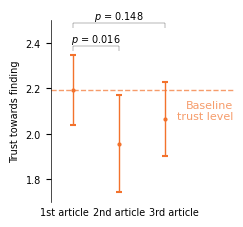

In [22]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(findingToPlot, color=condition1)
ax.set_ylabel('Trust towards finding')
ax.set_ylim(1.7, 2.5)

ax.set_yticks([1.8, 2, 2.2, 2.4])
plt.savefig('./figures/pilot_finding_c.pdf',bbox_inches = 'tight', pad_inches = 0)

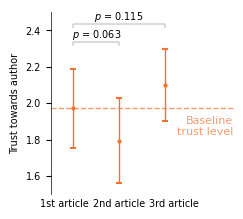

In [23]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(authorToPlot)
ax.set_ylabel('Trust towards author')
ax.set_ylim(1.5, 2.5)
ax.set_yticks([1.6, 1.8, 2, 2.2, 2.4])

plt.savefig('./figures/pilot_author_c1.pdf',bbox_inches = 'tight', pad_inches = 0)

#### Actual

In [24]:
findingToPlot = pd.concat([
    survey[['TRUST_FINDING_1','condition']].assign(Q=1).rename(columns={'TRUST_FINDING_1':'Trust'}),
    survey[['TRUST_FINDING_2','condition']].assign(Q=2).rename(columns={'TRUST_FINDING_2':'Trust'}),
    survey[['TRUST_FINDING_3','condition']].assign(Q=3).rename(columns={'TRUST_FINDING_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 1')

authorToPlot = pd.concat([
    survey[['TRUST_AUTHOR_1','condition']].assign(Q=1).rename(columns={'TRUST_AUTHOR_1':'Trust'}),
    survey[['TRUST_AUTHOR_2','condition']].assign(Q=2).rename(columns={'TRUST_AUTHOR_2':'Trust'}),
    survey[['TRUST_AUTHOR_3','condition']].assign(Q=3).rename(columns={'TRUST_AUTHOR_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 1')

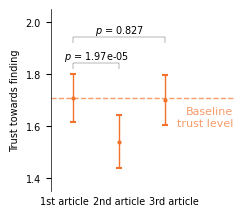

In [25]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(findingToPlot, color=condition1)
ax.set_ylabel('Trust towards finding')


plt.savefig('./figures/finding_condition1.pdf',bbox_inches = 'tight', pad_inches = 0)

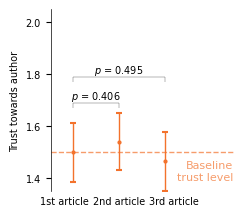

In [26]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(authorToPlot)
ax.set_ylabel('Trust towards author')


plt.savefig('./figures/author_c1.pdf',bbox_inches = 'tight', pad_inches = 0)

### Condition 2

#### Pilot

In [27]:
findingToPlot = pd.concat([
    pilot[['TRUST_FINDING_1','condition']].assign(Q=1).rename(columns={'TRUST_FINDING_1':'Trust'}),
    pilot[['TRUST_FINDING_2','condition']].assign(Q=2).rename(columns={'TRUST_FINDING_2':'Trust'}),
    pilot[['TRUST_FINDING_3','condition']].assign(Q=3).rename(columns={'TRUST_FINDING_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 2')

findingToPlot['Trust_jittered'] = findingToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(findingToPlot))

authorToPlot = pd.concat([
    pilot[['TRUST_AUTHOR_1','condition']].assign(Q=1).rename(columns={'TRUST_AUTHOR_1':'Trust'}),
    pilot[['TRUST_AUTHOR_2','condition']].assign(Q=2).rename(columns={'TRUST_AUTHOR_2':'Trust'}),
    pilot[['TRUST_AUTHOR_3','condition']].assign(Q=3).rename(columns={'TRUST_AUTHOR_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 2')

authorToPlot['Trust_jittered'] = authorToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(authorToPlot))

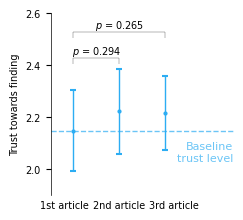

In [28]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(findingToPlot, color=condition2)
ax.set_ylabel('Trust towards finding')
ax.set_ylim(1.9, 2.5)

ax.set_yticks([2, 2.2, 2.4, 2.6])

plt.savefig('./figures/pilot_finding_c2.pdf',bbox_inches = 'tight', pad_inches = 0)

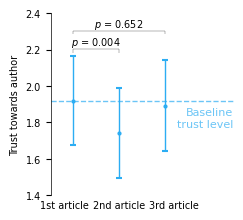

In [29]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(authorToPlot, color=condition2)
ax.set_ylabel('Trust towards author')
ax.set_ylim(1.4, 2.4)

ax.set_yticks([1.4, 1.6, 1.8, 2, 2.2, 2.4])

plt.savefig('./figures/pilot_author_c2.pdf',bbox_inches = 'tight', pad_inches = 0)

#### Actual

In [30]:
findingToPlot = pd.concat([
    survey[['TRUST_FINDING_1','condition']].assign(Q=1).rename(columns={'TRUST_FINDING_1':'Trust'}),
    survey[['TRUST_FINDING_2','condition']].assign(Q=2).rename(columns={'TRUST_FINDING_2':'Trust'}),
    survey[['TRUST_FINDING_3','condition']].assign(Q=3).rename(columns={'TRUST_FINDING_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 2')

findingToPlot['Trust_jittered'] = findingToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(findingToPlot))

authorToPlot = pd.concat([
    survey[['TRUST_AUTHOR_1','condition']].assign(Q=1).rename(columns={'TRUST_AUTHOR_1':'Trust'}),
    survey[['TRUST_AUTHOR_2','condition']].assign(Q=2).rename(columns={'TRUST_AUTHOR_2':'Trust'}),
    survey[['TRUST_AUTHOR_3','condition']].assign(Q=3).rename(columns={'TRUST_AUTHOR_3':'Trust'}),
    
], ignore_index=True, sort=False).query('condition == 2')

authorToPlot['Trust_jittered'] = authorToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(authorToPlot))

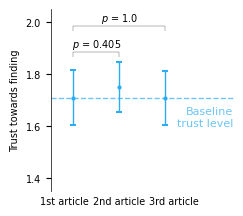

In [31]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(findingToPlot, color=condition2)
ax.set_ylabel('Trust towards finding')


plt.savefig('./figures/finding_c2.pdf',bbox_inches = 'tight', pad_inches = 0)

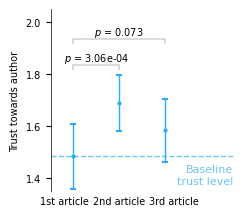

In [32]:
plt.figure(figsize=(6*cm, 6*cm))

ax = plot(authorToPlot, color=condition2)
ax.set_ylabel('Trust towards author')


plt.savefig('./figures/author_c2.pdf',bbox_inches = 'tight', pad_inches = 0)

## Effect of disclosure

In [33]:
[(q, c) for q in [2, 3] for c in [1, 2]]

[(2, 1), (2, 2), (3, 1), (3, 2)]

In [34]:
def plotDiff(df, ax=None):
    
    if ax is None:
        ax = plt.gca()
    
    yerr = [1.96 * df.query(f'Q=={q}').Trust.std()/math.sqrt(df.query(f'Q=={q}').shape[0]) for q in [2, 3] for c in [1, 2]]
    y = [df.query(f'Q=={q}').query(f'condition=={c}').Trust.mean() for q in [2, 3] for c in [1, 2]]
    ytop = [y[i] + yerr[i] for i in range(len(y))]
    
    plt.errorbar(
        x = [0, 1.5],
        y = [y[0], y[2]],
        yerr = [yerr[0], yerr[2]],
        color=condition1['error'], ls='none', marker='o', capsize=2, zorder=100, elinewidth=1, capthick=1.5, markersize=2
    )
    
    plt.errorbar(
        x = [0.5, 2],
        y = [y[1], y[3]],
        yerr = [yerr[1], yerr[3]],
        color=condition2['error'], ls='none', marker='o', capsize=2, zorder=100, elinewidth=1, capthick=1.5, markersize=2
    )
    
    baseline=df.query('Q==1').Trust.mean()
    
    ax.plot([-0.5, 3.5], [baseline, baseline], ls='--', lw=1.5, color='#f8961e')
    ax.text(x=3.5, y=baseline*0.95, s='Baseline\ntrust level', color='#f8961e',
            horizontalalignment='right', verticalalignment='top', fontsize=8)
    
    
    pval = ttest_ind(
        df.query(f'Q==2').query(f'condition==1').Trust,
        df.query(f'Q==2').query(f'condition==2').Trust
    )
    plotPvalue(ax, [0, 0.5], max(ytop[0], ytop[1]), pval.pvalue, scale=0.2)
    
    pval = ttest_ind(
        df.query(f'Q==3').query(f'condition==1').Trust,
        df.query(f'Q==3').query(f'condition==2').Trust
    )
    plotPvalue(ax, [1.5, 2], max(ytop[2], ytop[3]), pval.pvalue, scale=0.2)
    
    ax.set_xlim(-0.5, 2.25)
    ax.set_ylim(-0.25, 0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.tick_params(length=0, axis='x')
    
    ax.set_xticks([0.25, 1.75])
    ax.set_xticklabels(['2nd article', '3rd article'])
    
    ax.set_xlabel('')
    
    return ax

#### Pilot

In [35]:
# compute the difference between answer to question 2 and 3 against question 1
surveyDiff = (
    pilot
    .assign(Diff_2 = lambda df: df.TRUST_FINDING_2 - df.TRUST_FINDING_1)
    .assign(Diff_3 = lambda df: df.TRUST_FINDING_3 - df.TRUST_FINDING_1)
)

findingToPlot = pd.concat([
    surveyDiff[['Diff_2','condition']].assign(Q=2).rename(columns={'Diff_2':'Trust'}),
    surveyDiff[['Diff_3','condition']].assign(Q=3).rename(columns={'Diff_3':'Trust'}),
    
], ignore_index=True, sort=False)

surveyDiff = (
    pilot
    .assign(Diff_2 = lambda df: df.TRUST_AUTHOR_2 - df.TRUST_AUTHOR_1)
    .assign(Diff_3 = lambda df: df.TRUST_AUTHOR_3 - df.TRUST_AUTHOR_1)
)

authorToPlot = pd.concat([
    surveyDiff[['Diff_2','condition']].assign(Q=2).rename(columns={'Diff_2':'Trust'}),
    surveyDiff[['Diff_3','condition']].assign(Q=3).rename(columns={'Diff_3':'Trust'}),
    
], ignore_index=True, sort=False)

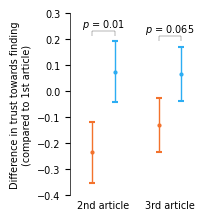

In [36]:
plt.figure(figsize=(4*cm, 6*cm))

ax = plotDiff(findingToPlot)
ax.set_ylabel('Difference in trust towards finding\n(compared to 1st article)')
ax.set_ylim(-0.4, 0.3)

plt.savefig('./figures/pilot_finding_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

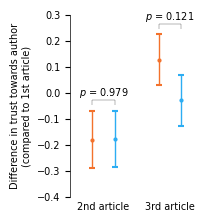

In [37]:
plt.figure(figsize=(4*cm, 6*cm))

ax = plotDiff(authorToPlot)
ax.set_ylabel('Difference in trust towards author\n(compared to 1st article)')
ax.set_ylim(-0.4, 0.3)

plt.savefig('./figures/pilot_author_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

#### Actual

In [38]:
# compute the difference between answer to question 2 and 3 against question 1
surveyDiff = (
    survey
    .assign(Diff_2 = lambda df: df.TRUST_FINDING_2 - df.TRUST_FINDING_1)
    .assign(Diff_3 = lambda df: df.TRUST_FINDING_3 - df.TRUST_FINDING_1)
)

findingToPlot = pd.concat([
    surveyDiff[['Diff_2','condition']].assign(Q=2).rename(columns={'Diff_2':'Trust'}),
    surveyDiff[['Diff_3','condition']].assign(Q=3).rename(columns={'Diff_3':'Trust'}),
    
], ignore_index=True, sort=False)

findingToPlot['Trust_jittered'] = findingToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(findingToPlot))

surveyDiff = (
    survey
    .assign(Diff_2 = lambda df: df.TRUST_AUTHOR_2 - df.TRUST_AUTHOR_1)
    .assign(Diff_3 = lambda df: df.TRUST_AUTHOR_3 - df.TRUST_AUTHOR_1)
)


authorToPlot = pd.concat([
    surveyDiff[['Diff_2','condition']].assign(Q=2).rename(columns={'Diff_2':'Trust'}),
    surveyDiff[['Diff_3','condition']].assign(Q=3).rename(columns={'Diff_3':'Trust'}),
    
], ignore_index=True, sort=False)

authorToPlot['Trust_jittered'] = authorToPlot['Trust'] + np.random.uniform(-0.1, 0.1, size=len(authorToPlot))

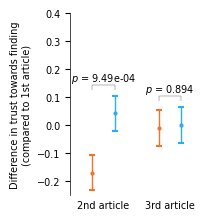

In [39]:
plt.figure(figsize=(4*cm, 6*cm))

ax = plotDiff(findingToPlot)
ax.set_ylabel('Difference in trust towards finding\n(compared to 1st article)')

plt.savefig('./figures/finding_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)

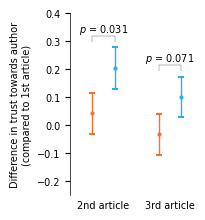

In [40]:
plt.figure(figsize=(4*cm, 6*cm))

ax = plotDiff(authorToPlot)
ax.set_ylabel('Difference in trust towards author\n(compared to 1st article)')

plt.savefig('./figures/author_DiD.pdf',bbox_inches = 'tight', pad_inches = 0)